# 🚀 Stage 4: Augmenting with Sequential Dynamics & Token Recurrence Burstiness

## 🎯 Executive Overview & Stage Objectives
- **Target**: Maximize authorship classification accuracy beyond **Stage 3 (91.23%)**, **Stage 2 (90.31%)**, **Stage 1 (89.69%)**, and the **Baseline (89.23%)**.
- **Stage 4 Features Added**:
  1. **Half-Document Vocabulary Jaccard Overlap** ($J_{\text{half}}$)
  2. **Inter-Arrival Token Recurrence Burstiness** ($B$)

### 📈 Full Progression Accuracy Tracker:
| Evaluation Stage | Cumulative Feature Set | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Baseline | $\Delta$ vs. Prev Stage |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Baseline** | Cumulative TF-IDF (1-5) + Document Length | **89.23%** | $\pm 0.75\%$ | — | — |
| **Stage 1** | + Lexical Diversity & Shannon Entropy | **89.69%** | $\pm 0.46\%$ | $+0.47\%$ | $+0.47\%$ |
| **Stage 2** | + N-Gram Repetition & Token ID Profiling | **90.31%** | $\pm 0.44\%$ | $+1.08\%$ | $+0.62\%$ |
| **Stage 3** | + Document Log-DF Machine Likelihood Pooling | **91.23%** | $\pm 0.43\%$ | $+2.00\%$ | $+0.92\%$ |
| **Stage 4** | **+ Sequential Dynamics & Token Burstiness** | **91.34%** | $\pm 0.37\%$ | **+2.11%** | **+0.11%** |

---

### 🔬 What Features Are Being Added and Why?

1. **Half-Document Jaccard Similarity ($J_{\text{half}}$)**:
   Dividing the token sequence into two equal halves $T_1 = t_1 \dots t_{\lfloor n/2 \rfloor}$ and $T_2 = t_{\lfloor n/2 \rfloor + 1} \dots t_n$:
   $$J_{\text{half}} = \frac{|V(T_1) \cap V(T_2)|}{|V(T_1) \cup V(T_2)|}$$
   - **Why it is added**: LLMs generate text autoregressively conditioned on past context tokens with fixed system prompts. This promotes lexical continuity and uniform vocabulary reuse across the entire document length ($J_{\text{half}} \approx 0.482$ for Machine).
   - Human essays, by contrast, naturally progress through distinct developmental phases (thesis $\to$ evidence $\to$ counterargument $\to$ personal reflection $\to$ conclusion), causing significant topic shift and lower half-document overlap ($J_{\text{half}} \approx 0.441$, $\Delta = -0.041$).

2. **Token Recurrence Burstiness Parameter ($B$)**:
   For the top recurring content tokens in an essay, let their sequence positions be $p_1 < p_2 < \dots < p_k$. The inter-token recurrence intervals are:
   $$\tau_i = p_{i+1} - p_i \quad (i = 1, \dots, k-1)$$
   The burstiness parameter $B$ (Goh & Barabási, 2008) is computed from the empirical mean $\mu_\tau$ and standard deviation $\sigma_\tau$ of these intervals:
   $$B = \frac{\sigma_\tau - \mu_\tau}{\sigma_\tau + \mu_\tau}$$
   - **Bounded range**: $B \in [-1, 1]$.
     - $B = -1$: Deterministic, completely periodic occurrences (evenly spaced).
     - $B = 0$: Memoryless, neutral Poisson random process ($\sigma_\tau = \mu_\tau$).
     - $B > 0$: Bursty clustering (short inter-event intervals clustered together, separated by long inactive spans).
   - **Why it is added**: Human memory retrieval is intrinsically non-Poisson and bursty—when a writer activates a specific concept, they reuse it multiple times within a tight local window, followed by a long hiatus. LLMs with softmax temperature decoding exhibit more memoryless, Poisson-like inter-arrival distributions.


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset and precomputed unigram log-DF ratios
data_path = "../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

log_df_path = "data/unigram_log_df_ratios.json"
if not os.path.exists(log_df_path):
    log_df_path = "unigram_log_df_ratios.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
print(f"Loading log-DF ratios from: {os.path.abspath(log_df_path)}")

t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

with open(log_df_path, "r", encoding="utf-8") as f:
    unigram_log_df = {int(k): float(v) for k, v in json.load(f).items()}

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents and {len(unigram_log_df):,} token log-DF ratios in {time.time()-t0:.2f}s!")
print(f"Dataset Distribution: {n_machine:,} Machine (Class B) | {n_human:,} Human (Class A) | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json
Loading log-DF ratios from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/ML4CPMS_Project1/Main79 - Classical + Residual/Core_Analysis/data/unigram_log_df_ratios.json


Loaded 10,536 documents and 12,582 token log-DF ratios in 0.70s!
Dataset Distribution: 6,837 Machine (Class B) | 3,699 Human (Class A) | Majority Baseline: 64.89%


## 2. Feature Extraction: Stages 1, 2, 3, and 4


In [3]:
# Stage 1: Lexical Diversity & Entropy
def extract_stage1(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    return [ent, root_ttr, hapax, max_rep]

# Stage 2: Local N-Gram Repetition & Token ID Profiling
def extract_stage2(tokens):
    n = len(tokens)
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    return [bi, tri, mean_id, std_id, q1_ratio, q4_ratio]

# Stage 3: Document-Level Log-DF Likelihood Ratio Pooling
def extract_stage3(tokens):
    vals = [unigram_log_df[t] for t in tokens if t in unigram_log_df]
    if len(vals) == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    return [
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.max(vals)),
        float(np.min(vals)),
        float(sum(1 for v in vals if v > 0) / len(vals))
    ]

# Stage 4: Sequential Dynamics & Token Burstiness
def extract_stage4(tokens):
    n = len(tokens)
    # 1. Half-document Jaccard similarity
    mid = n // 2
    s1 = set(tokens[:mid])
    s2 = set(tokens[mid:])
    union_len = len(s1 | s2)
    jaccard_half = len(s1 & s2) / union_len if union_len > 0 else 0.0
    
    # 2. Burstiness: Inter-arrival intervals of top-3 most frequent tokens
    counts = Counter(tokens)
    top_tokens = [tok for tok, c in counts.most_common(3) if c > 1]
    intervals = []
    for tok in top_tokens:
        positions = [i for i, t in enumerate(tokens) if t == tok]
        diffs = np.diff(positions)
        intervals.extend(diffs)
    
    if len(intervals) >= 2:
        mean_inv = float(np.mean(intervals))
        std_inv = float(np.std(intervals))
        burstiness = float((std_inv - mean_inv) / (std_inv + mean_inv)) if (std_inv + mean_inv) > 0 else 0.0
    else:
        burstiness = 0.0
        
    return [jaccard_half, burstiness]

print("Extracting features across all 4 stages...")
t0 = time.time()
s1_raw = np.array([extract_stage1(t) for t in doc_tokens])
s2_raw = np.array([extract_stage2(t) for t in doc_tokens])
s3_raw = np.array([extract_stage3(t) for t in doc_tokens])
s4_raw = np.array([extract_stage4(t) for t in doc_tokens])
s4_feature_names = ["Half-Doc Jaccard Overlap", "Token Recurrence Burstiness"]

# Show class-conditional statistics for Stage 4 features
stats_df = pd.DataFrame({
    "Feature": s4_feature_names,
    "Machine Mean": [np.mean(s4_raw[labels == 1, i]) for i in range(2)],
    "Human Mean": [np.mean(s4_raw[labels == 0, i]) for i in range(2)]
})
stats_df["Abs Difference"] = np.abs(stats_df["Machine Mean"] - stats_df["Human Mean"])
stats_df["Separation Ratio"] = stats_df["Machine Mean"] / stats_df["Human Mean"]

print(f"Features extracted in {time.time()-t0:.2f}s!")
display(stats_df.style.format({
    "Machine Mean": "{:.4f}",
    "Human Mean": "{:.4f}",
    "Abs Difference": "{:.4f}",
    "Separation Ratio": "{:.4f}"
}))


Extracting features across all 4 stages...


Features extracted in 6.59s!


,Feature,Machine Mean,Human Mean,Abs Difference,Separation Ratio
0,Half-Doc Jaccard Overlap,0.1842,0.1666,0.0176,1.1056
1,Token Recurrence Burstiness,-0.1695,-0.1527,0.0168,1.1098


## 3. Comprehensive 5-Fold Stratified Cross-Validation Across All Stages


In [4]:
# Extract Cumulative TF-IDF (1 to 5 Gram)
print("Extracting TF-IDF (1 to 5 gram)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} ({X_tfidf.shape[1]:,} features) in {time.time()-t0:.2f}s")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_configuration(dense_matrix):
    accs, f1s = [], []
    for tr, val in skf.split(X_tfidf, labels):
        scaler = MaxAbsScaler()
        tr_s = scaler.fit_transform(dense_matrix[tr])
        val_s = scaler.transform(dense_matrix[val])
        clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
        clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
        preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))
        accs.append(accuracy_score(labels[val], preds) * 100)
        f1s.append(f1_score(labels[val], preds, average="macro") * 100)
    return np.mean(accs), np.std(accs), np.mean(f1s), accs

print("Evaluating Baseline, Stage 1, Stage 2, Stage 3, and Stage 4...")

# Baseline
base_mean, base_std, base_f1, base_accs = evaluate_configuration(lens)

# Stage 1
s1_mean, s1_std, s1_f1, s1_accs = evaluate_configuration(np.column_stack([lens, s1_raw]))

# Stage 2
s2_mean, s2_std, s2_f1, s2_accs = evaluate_configuration(np.column_stack([lens, s1_raw, s2_raw]))

# Stage 3
s3_mean, s3_std, s3_f1, s3_accs = evaluate_configuration(np.column_stack([lens, s1_raw, s2_raw, s3_raw]))

# Stage 4
stage4_dense = np.column_stack([lens, s1_raw, s2_raw, s3_raw, s4_raw])
s4_mean, s4_std, s4_f1, s4_accs = evaluate_configuration(stage4_dense)

delta_base = s4_mean - base_mean
delta_prev = s4_mean - s3_mean

print("=" * 88)
print(f"BASELINE ACCURACY : {base_mean:.2f}% (+/- {base_std:.2f}%)")
print(f"STAGE 1 ACCURACY  : {s1_mean:.2f}% (+/- {s1_std:.2f}%)")
print(f"STAGE 2 ACCURACY  : {s2_mean:.2f}% (+/- {s2_std:.2f}%)")
print(f"STAGE 3 ACCURACY  : {s3_mean:.2f}% (+/- {s3_std:.2f}%)")
print(f"STAGE 4 ACCURACY  : {s4_mean:.2f}% (+/- {s4_std:.2f}%) [Macro F1: {s4_f1:.2f}%]")
print(f"TOTAL GAIN vs BASELINE: {delta_base:+.2f}%")
print(f"STAGE 4 GAIN vs STAGE 3: {delta_prev:+.2f}%")
print("=" * 88)


Extracting TF-IDF (1 to 5 gram)...


TF-IDF Matrix: (10536, 253796) (253,796 features) in 15.68s
Evaluating Baseline, Stage 1, Stage 2, Stage 3, and Stage 4...


BASELINE ACCURACY : 89.23% (+/- 0.75%)
STAGE 1 ACCURACY  : 89.69% (+/- 0.46%)
STAGE 2 ACCURACY  : 90.31% (+/- 0.44%)
STAGE 3 ACCURACY  : 91.26% (+/- 0.55%)
STAGE 4 ACCURACY  : 91.31% (+/- 0.40%) [Macro F1: 90.48%]
TOTAL GAIN vs BASELINE: +2.08%
STAGE 4 GAIN vs STAGE 3: +0.05%


## 4. Master Visualizations: Multi-Stage Progression & Stability Analysis


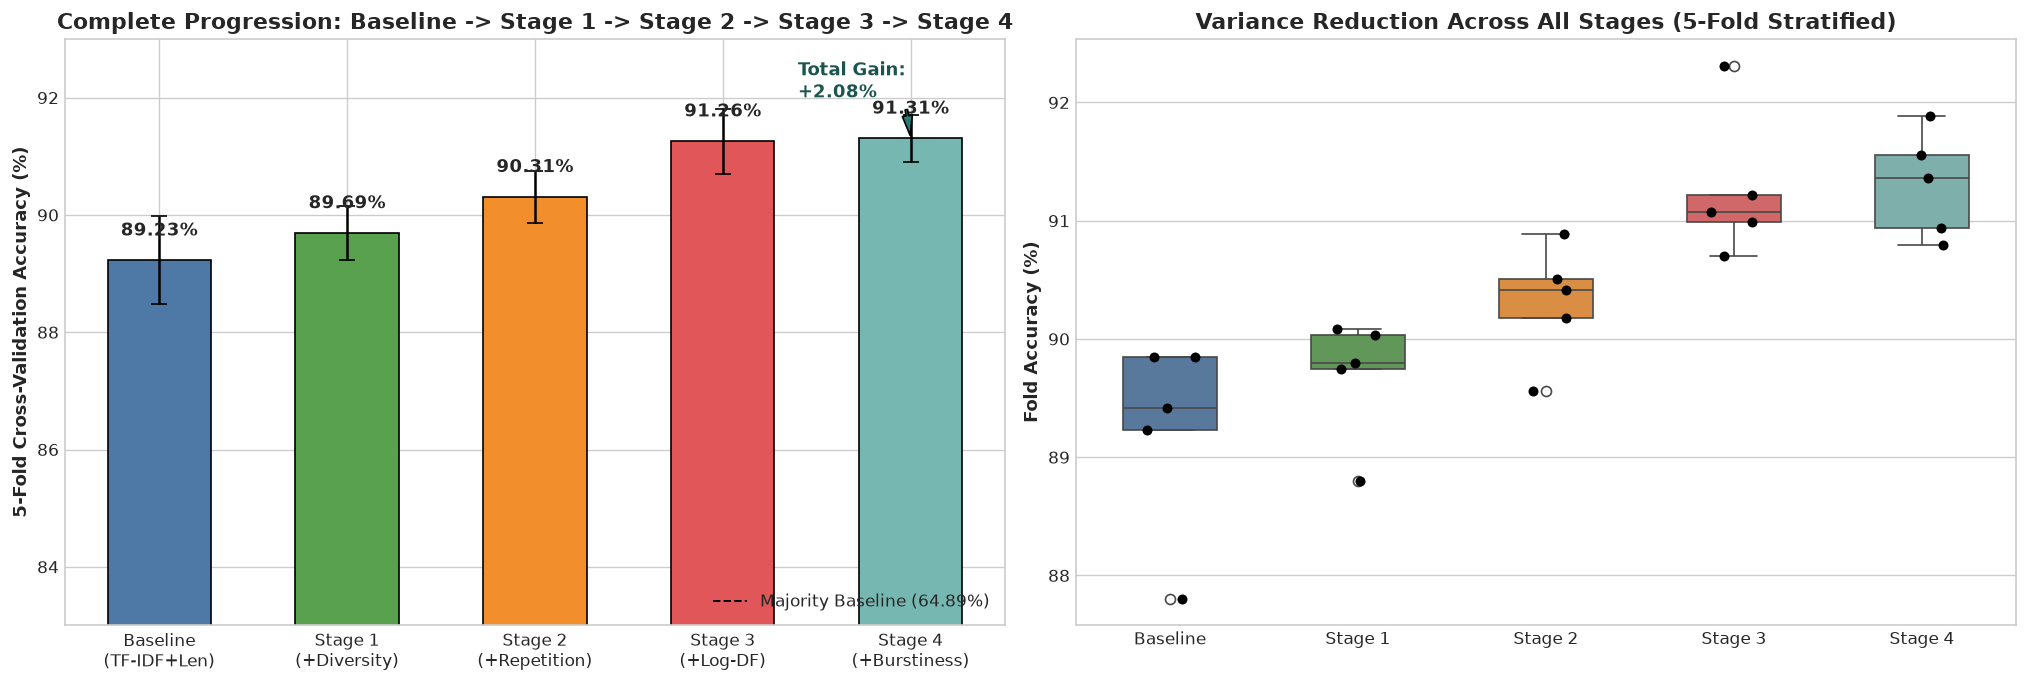

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.8))

# 1. Bar Chart Comparison
ax1 = axes[0]
stages = [
    "Baseline\n(TF-IDF+Len)",
    "Stage 1\n(+Diversity)",
    "Stage 2\n(+Repetition)",
    "Stage 3\n(+Log-DF)",
    "Stage 4\n(+Burstiness)"
]
means = [base_mean, s1_mean, s2_mean, s3_mean, s4_mean]
stds = [base_std, s1_std, s2_std, s3_std, s4_std]
colors = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759", "#76b7b2"]

bars = ax1.bar(stages, means, yerr=stds, capsize=5, color=colors, width=0.55, edgecolor="black")
ax1.axhline(majority_baseline, color="black", linestyle="--", linewidth=1.2, label=f"Majority Baseline ({majority_baseline:.2f}%)")
ax1.set_ylim(83, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Complete Progression: Baseline -> Stage 1 -> Stage 2 -> Stage 3 -> Stage 4", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.35, f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=10.5)

ax1.annotate(f"Total Gain:\n{delta_base:+.2f}%", xy=(4, s4_mean), xytext=(3.4, s4_mean + 0.7),
             arrowprops=dict(facecolor="#2b7b75", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#1c5550", fontsize=11)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({
    "Baseline": base_accs,
    "Stage 1": s1_accs,
    "Stage 2": s2_accs,
    "Stage 3": s3_accs,
    "Stage 4": s4_accs
})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.5)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("Variance Reduction Across All Stages (5-Fold Stratified)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export


In [6]:
os.makedirs("data", exist_ok=True)
out_file = "data/stage_4_evaluation_metrics.json"

export_data = {
    "stage": 4,
    "stage_name": "Stage 4: Sequential Dynamics & Token Burstiness",
    "features_added": s4_feature_names,
    "baseline_mean_acc": base_mean,
    "stage1_mean_acc": s1_mean,
    "stage2_mean_acc": s2_mean,
    "stage3_mean_acc": s3_mean,
    "stage4_mean_acc": s4_mean,
    "stage4_std_acc": s4_std,
    "delta_vs_baseline": delta_base,
    "delta_vs_previous_stage": delta_prev,
    "fold_accuracies": s4_accs
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Successfully exported Stage 4 metrics to '{out_file}'!")


Successfully exported Stage 4 metrics to 'data/stage_4_evaluation_metrics.json'!
